### Section 1 - Question 1


In [17]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [18]:
# read dataset
csv_path = r"/Users/wangxiaoxiao/Desktop/1st/males_ht_wt_cntry.csv"
df = pd.read_csv(csv_path)


In [19]:
# preview dataset and basic checks
display(df.head())
print("Shape (rows, cols):", df.shape)
print("Columns:", list(df.columns))
print("Data types:")
print(df.dtypes)
print("\nCountry counts:")
print(df["Country"].value_counts())


,Height,Weight,Country
0,64.0,144.0,Italy
1,68.0,150.0,Italy
2,66.0,147.0,Italy
3,71.0,170.0,Italy
4,65.0,163.0,Italy


Shape (rows, cols): (240, 3)
Columns: ['Height', 'Weight', 'Country']
Data types:
Height     float64
Weight     float64
Country     object
dtype: object

Country counts:
Country
USA            90
Netherlands    80
Italy          70
Name: count, dtype: int64


### Section 1 - Question 2
#### Histograms


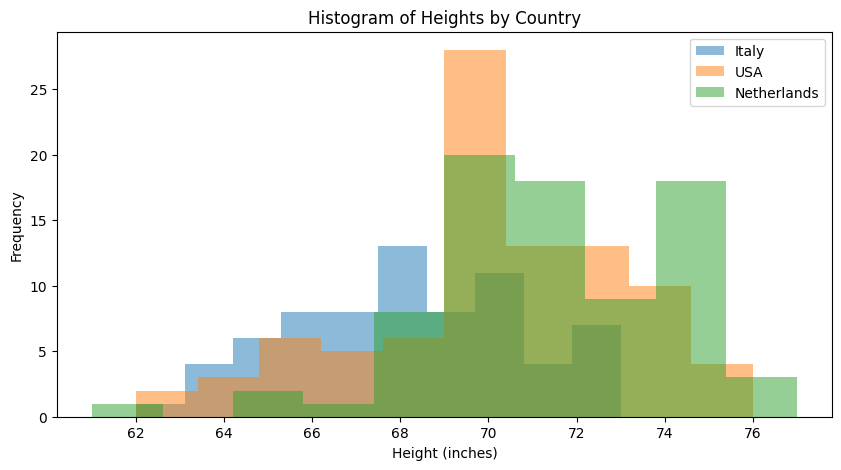

In [20]:
# histogram of heights by country
plt.figure(figsize=(10,5))
for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    plt.hist(subset["Height"], bins=10, alpha=0.5, label=country)
plt.xlabel("Height (inches)")
plt.ylabel("Frequency")
plt.title("Histogram of Heights by Country")
plt.legend()
plt.show()


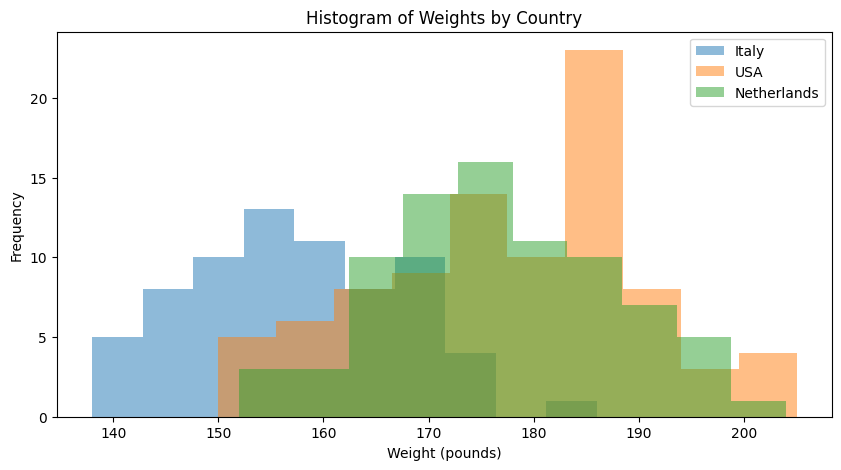

In [21]:
# histogram of weights by country
plt.figure(figsize=(10,5))
for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    plt.hist(subset["Weight"], bins=10, alpha=0.5, label=country)
plt.xlabel("Weight (pounds)")
plt.ylabel("Frequency")
plt.title("Histogram of Weights by Country")
plt.legend()
plt.show()


### Section 1 - Question 3
#### ANOVA (Weights by Country)


In [22]:
# prepare groups
usa_w = df.loc[df["Country"] == "USA", "Weight"]
nl_w  = df.loc[df["Country"] == "Netherlands", "Weight"]
it_w  = df.loc[df["Country"] == "Italy", "Weight"]

print("Group sizes:", len(usa_w), len(nl_w), len(it_w))
print("Means (no rounding):")
print("USA:", usa_w.mean())
print("Netherlands:", nl_w.mean())
print("Italy:", it_w.mean())


Group sizes: 90 80 70
Means (no rounding):
USA: 177.43333333333334
Netherlands: 176.7125
Italy: 157.42857142857142


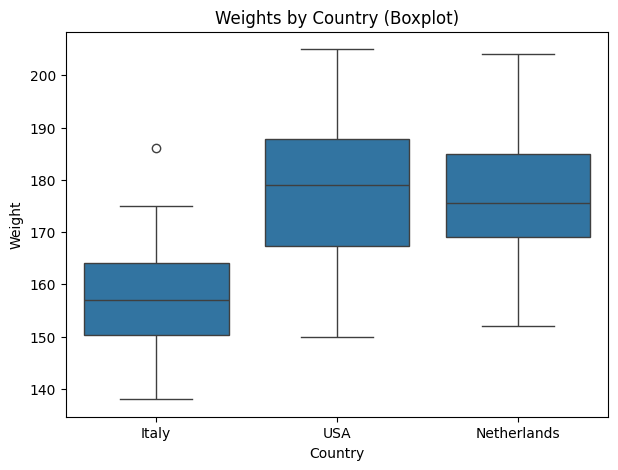

In [23]:
# visualization (boxplot)
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Country", y="Weight")
plt.title("Weights by Country (Boxplot)")
plt.show()


In [24]:
# Levene's test for homogeneity of variances
lev_stat, lev_p = stats.levene(usa_w, nl_w, it_w, center="median")
print("Levene's test statistic:", lev_stat)
print("Levene's test p-value:", lev_p)


Levene's test statistic: 2.657937494045452
Levene's test p-value: 0.07218180380373083


In [25]:
# One-way ANOVA (weights ~ country)
f_stat, p_val = stats.f_oneway(usa_w, nl_w, it_w)
print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_val)


ANOVA F-statistic: 73.0316861418844
ANOVA p-value: 1.9503368513081568e-25


### Section 1 - Question 4a
#### Italy vs Netherlands


In [26]:
# Italy vs Netherlands
it_w = df.loc[df["Country"] == "Italy", "Weight"]
nl_w = df.loc[df["Country"] == "Netherlands", "Weight"]

# Levene test for equal variances
lev_stat_it_nl, lev_p_it_nl = stats.levene(it_w, nl_w, center="median")
equal_var_it_nl = bool(lev_p_it_nl >= 0.05)

# independent two-sample t-test
t_stat_it_nl, p_val_it_nl = stats.ttest_ind(it_w, nl_w, equal_var=equal_var_it_nl)
print("Levene p (IT vs NL):", lev_p_it_nl)
print("t-stat (IT vs NL):", t_stat_it_nl)
print("p-value (IT vs NL):", p_val_it_nl)


Levene p (IT vs NL): 0.6039075096332414
t-stat (IT vs NL): -11.135754716464666
p-value (IT vs NL): 2.6541621479997745e-21


### Section 1 - Question 4b
#### USA vs Netherlands


In [27]:
# USA vs Netherlands
usa_w = df.loc[df["Country"] == "USA", "Weight"]
nl_w = df.loc[df["Country"] == "Netherlands", "Weight"]

# Levene test for equal variances
lev_stat_us_nl, lev_p_us_nl = stats.levene(usa_w, nl_w, center="median")
equal_var_us_nl = bool(lev_p_us_nl >= 0.05)

# independent two-sample t-test
t_stat_us_nl, p_val_us_nl = stats.ttest_ind(usa_w, nl_w, equal_var=equal_var_us_nl)
print("Levene p (USA vs NL):", lev_p_us_nl)
print("t-stat (USA vs NL):", t_stat_us_nl)
print("p-value (USA vs NL):", p_val_us_nl)


Levene p (USA vs NL): 0.10363867992326249
t-stat (USA vs NL): 0.3920914807972518
p-value (USA vs NL): 0.6954875719362548


### Section 1 - Question 5
#### Family-wise error rate (FWER) with 3 pairwise t-tests


In [28]:
# compute family-wise error rate (FWER) for multiple comparisons
alpha = 0.05      # per typical hypothesis testing threshold
m = 3             # three pairwise tests: IT vs NL, IT vs USA, USA vs NL

prob_no_false_positive = (1 - alpha) ** m      # P(none is a false positive)
fwer = 1 - prob_no_false_positive              # P(at least one false positive)

print("alpha:", alpha)
print("number_of_tests:", m)
print("P(none false positive) = (1 - alpha)^m:", prob_no_false_positive)
print("FWER = 1 - (1 - alpha)^m:", fwer)


alpha: 0.05
number_of_tests: 3
P(none false positive) = (1 - alpha)^m: 0.8573749999999999
FWER = 1 - (1 - alpha)^m: 0.1426250000000001


### Section 1 - Question 6
#### Tukey HSD multiple comparisons


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
      Italy Netherlands  19.2839    0.0 14.8586 23.7093   True
      Italy         USA  20.0048    0.0 15.6957 24.3138   True
Netherlands         USA   0.7208 0.9119  -3.434  4.8757  False
--------------------------------------------------------------


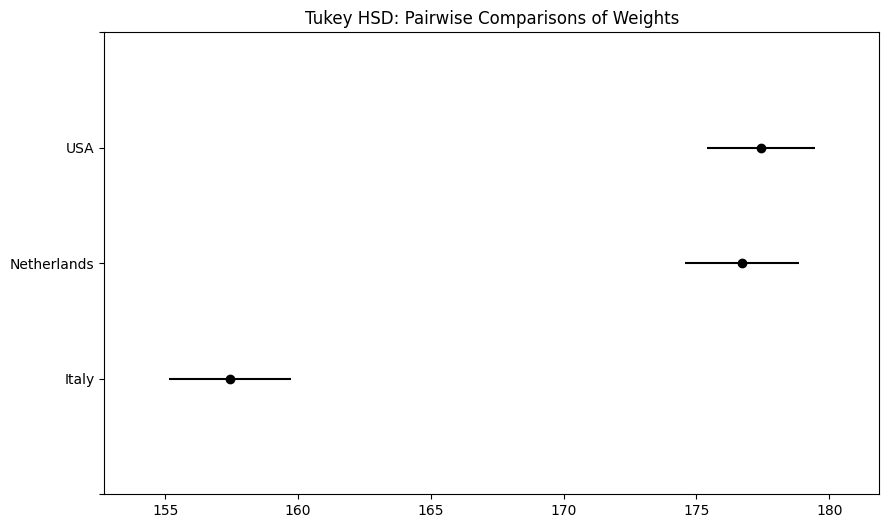

In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD test for weights by country
tukey = pairwise_tukeyhsd(endog=df["Weight"], groups=df["Country"], alpha=0.05)
print(tukey)

# optional: plot the Tukey HSD results
tukey.plot_simultaneous()
plt.title("Tukey HSD: Pairwise Comparisons of Weights")
plt.show()


### Section 2 - Question 1
#### Create BMI column (Imperial formula)


In [32]:
# BMI = Weight * 703 / (Height^2)
# Height is in inches; Weight is in pounds.
df["BMI"] = df["Weight"] * 703 / (df["Height"] ** 2)

# quick check
print("BMI column created. Preview:")
display(df[["Height", "Weight", "BMI"]].head(10))


BMI column created. Preview:


,Height,Weight,BMI
0,64.0,144.0,24.714844
1,68.0,150.0,22.804931
2,66.0,147.0,23.723829
3,71.0,170.0,23.707598
4,65.0,163.0,27.121657
5,67.0,161.0,25.213411
6,65.0,147.0,24.459408
7,68.0,156.0,23.717128
8,69.0,149.0,22.001050
9,66.0,157.0,25.337695


### Section 2 - Question 2
#### Create Overweight (1 if BMI >= 25, else 0)


In [33]:
df["Overweight"] = (df["BMI"] >= 25).astype(int)

# quick check
print("Overweight column created (1 if BMI>=25 else 0). Preview:")
display(df[["BMI", "Overweight", "Country"]].head(10))

# sanity check: counts
print("\nOverweight value counts:")
print(df["Overweight"].value_counts())


Overweight column created (1 if BMI>=25 else 0). Preview:


,BMI,Overweight,Country
0,24.714844,0,Italy
1,22.804931,0,Italy
2,23.723829,0,Italy
3,23.707598,0,Italy
4,27.121657,1,Italy
5,25.213411,1,Italy
6,24.459408,0,Italy
7,23.717128,0,Italy
8,22.001050,0,Italy
9,25.337695,1,Italy



Overweight value counts:
Overweight
0    140
1    100
Name: count, dtype: int64


### Section 2 - Question 3
#### Contingency table of Overweight by Country


In [34]:
import pandas as pd

# contingency table (counts)
ct = pd.crosstab(df["Overweight"], df["Country"])

# with totals to inspect (do not use margins table for chi-square)
ct_with_totals = pd.crosstab(df["Overweight"], df["Country"], margins=True, margins_name="Total")

print("Contingency table (counts):")
display(ct)

print("\nContingency table with totals (for inspection only):")
display(ct_with_totals)

# optional: row-wise percentages to describe differences
print("\nRow-wise percentages (Overweight 0/1 within each row):")
row_pct = ct.div(ct.sum(axis=1), axis=0)
display((row_pct * 100))


Contingency table (counts):


Country,Italy,Netherlands,USA
Overweight,,,
0,54,48,38
1,16,32,52



Contingency table with totals (for inspection only):


Country,Italy,Netherlands,USA,Total
Overweight,,,,
0,54,48,38,140
1,16,32,52,100
Total,70,80,90,240



Row-wise percentages (Overweight 0/1 within each row):


Country,Italy,Netherlands,USA
Overweight,,,
0,38.571429,34.285714,27.142857
1,16.000000,32.000000,52.000000


### Section 2 - Question 4
#### Chi-square test of independence (Overweight vs Country)


In [35]:
from scipy.stats import chi2_contingency

# use the counts table without totals
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("\nExpected frequencies (under independence):")
exp_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
display(exp_df)


Chi-square statistic: 19.892244897959184
p-value: 4.79130595387623e-05
Degrees of freedom: 2

Expected frequencies (under independence):


Country,Italy,Netherlands,USA
Overweight,,,
0,40.833333,46.666667,52.5
1,29.166667,33.333333,37.5
